# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices from
features such as area, location, number of rooms, and age — practicing the full workflow from
data cleaning through to model interpretation.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

> **A note on the dataset:** This notebook uses a **real** housing dataset ['Ames Housing Dataset'](https://www.kaggle.com/datasets/prevek18/ames-housing-dataset) whih is already downloaded and stored in ['data'](../data/raw/)
> so that the notebook runs end-to-end with no external downloads required.
>
> To use it with a **your own** dataset instead — simply replace the "Load Dataset" cell below with:
> ```python
> df = pd.read_csv("../data/raw/AmesHousing.csv")
> ```
> and adjust the column names in the "Feature Selection" section to match. Everything downstream
> (EDA, cleaning, encoding, modeling, evaluation) is written generically enough to keep working.


# Ames Housing — Linear Regression Price Prediction

End-to-end workflow: EDA → cleaning → feature engineering → feature selection →
Linear Regression → evaluation → interpretation → (bonus) Ridge/Lasso comparison.

**Dataset:** Ames Housing (`AmesHousing.csv`) — 2,930 rows, 82 columns (79 candidate features + Order/PID + target `SalePrice`).

In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [353]:
pd.set_option("display.max_columns", 85)
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_colwidth", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load Dataset

In [354]:
df = pd.read_csv("../data/raw/AmesHousing.csv")
print(f"Dataframe shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataframe shape: 2,930 rows x 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [355]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

## 2. Exploratory Data Analysis (EDA)

In [356]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [357]:
# Null chek — count and percentage of missing values in each column
null_counts = df.isnull().sum()
null_pct = ((null_counts / len(df)) * 100).round(2)
null_summary = pd.DataFrame({"Missing_Count": null_counts, "Missing_Pct": null_pct})
null_summary = null_summary[null_summary["Missing_Count"] > 0].sort_values(by="Missing_Pct", ascending=False)
null_summary

,Missing_Count,Missing_Pct
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


In [358]:
# descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


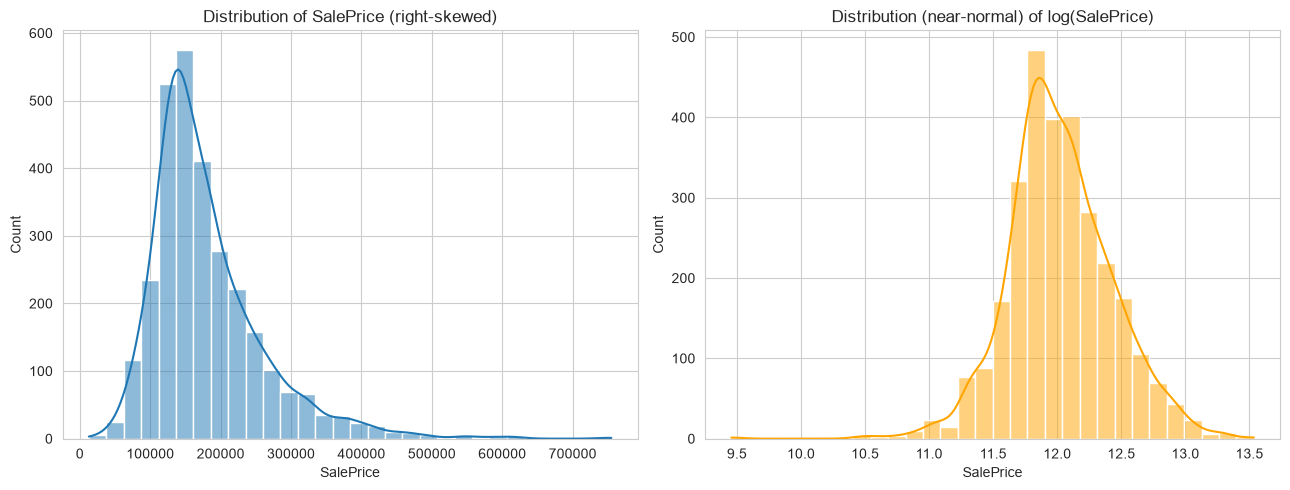

Skewness of SalePrice: 1.74
Skewness of log(SalePrice): -0.01


In [359]:
# Distribution of SalePrice (Target variable)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["SalePrice"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribution of SalePrice (right-skewed)")

# Distribution of log(SalePrice)
sns.histplot(np.log1p(df["SalePrice"]), bins=30, kde=True, ax=ax[1], color="orange")
ax[1].set_title("Distribution (near-normal) of log(SalePrice)")
plt.tight_layout()
plt.show()

print("Skewness of SalePrice:", df["SalePrice"].skew().round(2))
print("Skewness of log(SalePrice):", np.log1p(df["SalePrice"]).skew().round(2))


**Observation:** `SalePrice` is right-skewed (a handful of very expensive homes pull the mean above
the median). Linear Regression assumes roughly normal, homoscedastic residuals, so log-transforming
the target is a common, effective fix — we'll build the model on `log1p(SalePrice)` and convert
predictions back with `expm1()` at the end.

## 2. Feature Selection Discussion

**Columns to drop outright (no predictive value / pure identifiers):**

- `Order` — row index, artifact of how the file was saved, not a real feature.
- `PID` — Parcel ID, a unique identifier per property. It's a number, so `.corr()` will report a
  value for it, but that correlation is spurious (IDs were assigned in some arbitrary/administrative
  order, not derived from anything about the house). Any ID-type column should always be dropped
  before modeling — keeping it risks the model "memorizing" IDs instead of learning genuine
  price drivers.

**Columns that are almost entirely missing, where "missing" actually means "feature absent"
(`Pool QC`, `Misc Feature`, `Alley`, `Fence`):**
These are 80-99% NaN. According to the Ames data dictionary, NaN here doesn't mean *unknown* — it
means the house has no pool / no alley access / no fence / no extra misc feature. Rather than
dropping the information entirely, we engineer it into cheap binary flags (`Has Pool`, `Has Fence`,
etc.) and then drop the original high-cardinality, mostly-empty columns — this keeps the signal
("having a pool matters") without keeping 96%-empty categorical columns that add noise and
dimensionality once one-hot encoded.

**Likely strong predictors (by domain knowledge, confirmed below by correlation):**
`Overall Qual`, `Gr Liv Area` (above-ground living area), `Total Bsmt SF`, `1st Flr SF`,
`Garage Cars`/`Garage Area`, `Year Built`, `Full Bath`, `TotRms AbvGrd`, `Neighborhood`. These map
directly onto the "area, location, rooms, age" drivers named in the project objective.

**Redundant / multicollinear groups** (keep one, or an engineered combination, rather than all of them):
- `Garage Cars` & `Garage Area` — both measure garage size, correlate strongly with each other.
- `1st Flr SF`, `2nd Flr SF`, `Total Bsmt SF`, `Gr Liv Area` — overlapping measures of house size;
  we'll engineer a single `Total SF` feature from these.
- `TotRms AbvGrd` overlaps heavily with `Gr Liv Area` (more area → more rooms).

Linear Regression coefficients become unstable/hard to interpret under strong multicollinearity
(the model can't tell which correlated feature "deserves" the credit), so consolidating overlapping
size/count features into a few clean engineered features is both a cleaning step and a feature-selection step.

In [360]:
# Confirming the correlation between features and SalePrice
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_features].corr()['SalePrice'].sort_values(ascending=False)
correlation_matrix

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

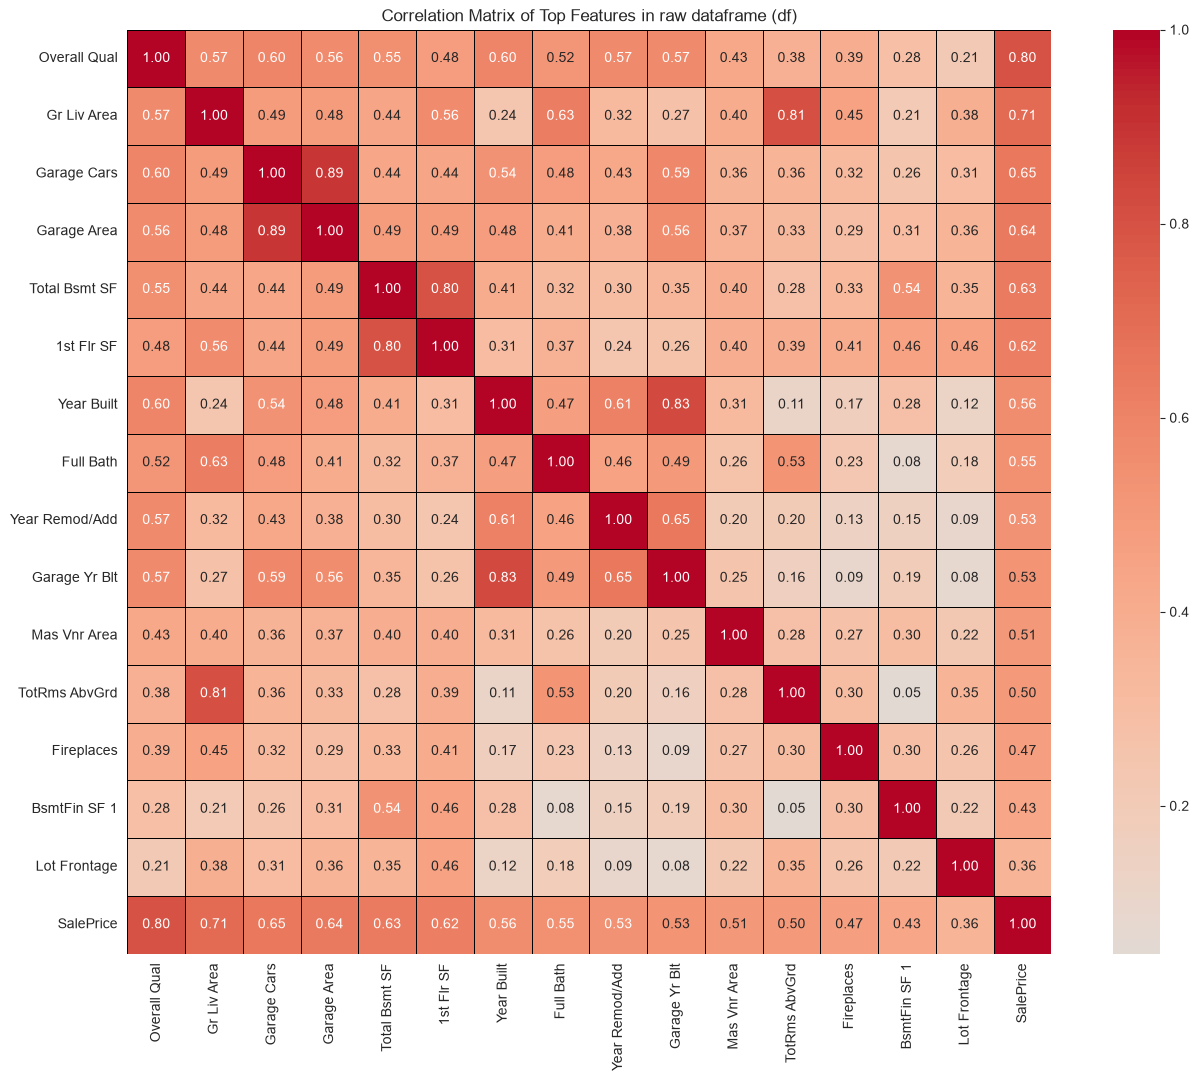

In [361]:
top_features = correlation_matrix[1:16].index.tolist()  # Exclude 'SalePrice' itself
plt.figure(figsize=(16, 12))
sns.heatmap(df[top_features + ['SalePrice']].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor='black', square=True)
plt.title("Correlation Matrix of Top Features in raw dataframe (df)")
plt.show()

## 3. Handle Missing Values, Feature Engineering, and Encoding

Missing values fall into three buckets, each handled differently — filling everything with a single
generic strategy (e.g. "drop all rows with NaN" or "fill everything with the mean") would either
throw away ~1,450 of 2,930 rows or corrupt columns where NaN is actually meaningful.

| Bucket | Columns | Strategy | Why |
|---|---|---|---|
| **NaN = "feature not present"** (categorical) | `Pool QC`, `Fence`, `Fireplace Qu`, `Garage Type/Finish/Qual/Cond`, `Bsmt Qual/Cond/Exposure/FinType1/FinType2`, `Mas Vnr Type`, `Alley`, `Misc Feature` | fill with the string `"None"` | NaN doesn't mean "unknown" here — the Ames data dictionary defines it as the house lacking that feature (no basement, no garage, etc.). Filling with the mode or dropping the rows would fabricate or discard real information. |
| **NaN = "feature not present"** (numeric) | `Garage Yr Blt`, `Garage Cars`, `Garage Area`, `Mas Vnr Area`, `Total Bsmt SF`, `Bsmt Full/Half Bath`, `BsmtFin SF 1/2`, `Bsmt Unf SF` | fill with `0` | Same logic as above, just for numeric companions — no garage means 0 garage cars/area, no basement means 0 basement sq ft. |
| **Genuinely missing / unrecorded** | `Lot Frontage` (16.7% missing), `Electrical` (1 row) | `Lot Frontage`: median **within each Neighborhood** (frontage is strongly tied to lot layout, which varies by neighborhood). `Electrical`: mode (only 1 missing row). | These aren't "absence of a feature" — the value exists but wasn't recorded, so we impute a reasonable estimate rather than a hardcoded 0/None. |

We also drop `Pool QC`, `Fence`, `Alley`, `Misc Feature` themselves *after* extracting their signal
into binary flags, since >80%-empty categorical columns add mostly noise once one-hot encoded.

In [362]:
data = df.copy()

In [363]:
# Drop pure identifier columns that do not contribute to the prediction
data = data.drop(columns=["Order", "PID"])

In [364]:
# Engineer 'has x' features for categorical columns with missing values
data['Has Pool'] = (data['Pool QC'].notna()).astype(int)
data['Has Fence'] = (data['Fence'].notna()).astype(int)
data['Has Alley'] = (data['Alley'].notna()).astype(int)
data['Has MiscFeature'] = (data['Misc Feature'].notna()).astype(int)
data = data.drop(columns=["Pool QC", "Fence", "Alley", "Misc Feature", 'Pool Area'])

In [365]:
# --- NaN = 'No Such Feature' for categorical columns with missing values, fill with 'None' (Categorical)
categorical_cols_with_missing = [
    'Mas Vnr Type', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 
    'Garage Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 
    'BsmtFin Type 2'
    ]
for col in categorical_cols_with_missing:
    data[col] = data[col].fillna('None')

In [366]:
# --- NaN = 0 for numeric columns with missing values, fill with 0 (Numeric)
numeric_cols_with_missing = [
    'Mas Vnr Area', 'Garage Yr Blt', 'BsmtFin SF 1', 'BsmtFin SF 2', 
    'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
    'Garage Cars', 'Garage Area'
]
for col in numeric_cols_with_missing:
    data[col] = data[col].fillna(0)  

In [367]:
# --- Genuinely missing : sensible imputation ---
data['Lot Frontage'] = data.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)
data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Lot Frontage'].median()) # safeguard in case some neighborhoods have all NaN values
data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

print("Remaining Missing values : ", data.isnull().sum().sum())

Remaining Missing values :  0


### Feature engineering

New features that compress correlated / overlapping raw columns into fewer, more informative ones —
this both aids interpretability and reduces multicollinearity:

- **`House Age`** = `Yr Sold − Year Built` (age at time of sale, more directly meaningful than a build year)
- **`Years Since Remod`** = `Yr Sold − Year Remod/Add`
- **`Total SF`** = `1st Flr SF + 2nd Flr SF + Total Bsmt SF` (single overall size measure)
- **`BsmtFin Ratio`** = (`BsmtFin SF 1` + `BsmtFin SF 2`) / `Total Bsmt SF`
- **`Total Bath`** = `Full Bath + 0.5*Half Bath + Bsmt Full Bath + 0.5*Bsmt Half Bath`
- **`Total Outdoor SF`** = `Open Porch SF + Enclosed Porch + 3Ssn Porch + Screen Porch + Wood Deck SF`
- **`Has Garage` / `Has Basement` / `Has Fireplace` / `Has Enclosed Porch` / `Has Screen Porch`** binary flags (in addition to the size/quality columns)

**Important:** each engineered feature above is an *exact* linear combination of raw columns still in
the dataset (e.g. `Total SF` is literally `1st Flr SF + 2nd Flr SF + Total Bsmt SF` added together).
Leaving both the engineered feature *and* all of its raw ingredients in the model creates perfect
multicollinearity — the design matrix becomes rank-deficient, and Linear Regression's coefficients
for that group become arbitrary/unstable (they can spread huge, cancelling values across the
redundant columns instead of anything interpretable). So once each engineered feature is created,
we drop the specific raw columns that were fully absorbed into it, keeping only the cleaner,
non-redundant version.

In [368]:
data['House Age'] = data['Yr Sold'] - data['Year Built']
data['Year Since Remod'] = data['Yr Sold'] - data['Year Remod/Add']
data['Total SF'] = data['Total Bsmt SF'] + data['1st Flr SF'] + data['2nd Flr SF']
data['Total Bath'] = data['Full Bath'] + (0.5 * data['Half Bath']) + data['Bsmt Full Bath'] + (0.5 * data['Bsmt Half Bath'])
data['BsmtFin Ratio'] = ((data['BsmtFin SF 1'] + data['BsmtFin SF 2']) / data['Total Bsmt SF'].replace(0, np.nan)).round(2)  # Avoid division by zero
data['BsmtFin Ratio'] = data['BsmtFin Ratio'].fillna(0)  # Replace NaN values with 0 for houses without a basement
data['Total Outdoor SF'] = data['Open Porch SF'] + data['Enclosed Porch'] + data['3Ssn Porch'] + data['Screen Porch'] + data['Wood Deck SF']

data['Has Enclosed Porch'] = (data['Enclosed Porch'] > 0).astype(int)
data['Has Screen Porch'] = (data['Screen Porch'] > 0).astype(int)
data['Has Garage'] = (data['Garage Area'] > 0).astype(int)
data['Has Basement'] = (data['Total Bsmt SF'] > 0).astype(int)  
data['Has Fireplace'] = (data['Fireplaces'] > 0).astype(int)

In [369]:
# Guard against negative values in 'Year Since Remod' and 'House Age' due to data entry errors
data['Year Since Remod'] = data['Year Since Remod'].apply(lambda x: max(x, 0))
data['House Age'] = data['House Age'].apply(lambda x: max(x, 0))

# Drop the raw columns that have been transformed into new features
data = data.drop(columns=[
    "Year Built", "Year Remod/Add", "1st Flr SF", "2nd Flr SF", "Full Bath", "Half Bath",
    "Bsmt Full Bath", "Bsmt Half Bath", 'BsmtFin SF 1', 'BsmtFin SF 2', 'Total Bsmt SF', 
    'Bsmt Unf SF', 'Garage Area', 'Fireplaces' , 'Open Porch SF', 'Enclosed Porch', 
    '3Ssn Porch', 'Screen Porch', 'Wood Deck SF', 
])

# Drop TotRms AbvGrd cause it is highly correlated with Gr Liv Area and droping it fixes the multicollinearity issue in the model
data = data.drop(columns=['TotRms AbvGrd'])

data[['House Age', 'Year Since Remod', 'Total SF', 'Total Bath', 'BsmtFin Ratio', 'Total Outdoor SF']].describe()

,House Age,Year Since Remod,Total SF,Total Bath,BsmtFin Ratio,Total Outdoor SF
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,36.434471,23.525256,2546.269283,2.217918,0.438454,182.891468
std,30.290941,20.857256,804.350838,0.807444,0.364178,159.834420
min,0.000000,0.000000,334.000000,1.000000,0.000000,0.000000
25%,7.000000,4.000000,2000.000000,1.500000,0.000000,48.000000
50%,34.000000,15.000000,2450.000000,2.000000,0.500000,165.000000
75%,54.000000,42.750000,2990.000000,2.500000,0.760000,266.000000
max,136.000000,60.000000,11752.000000,7.000000,1.000000,1424.000000


### Encoding categorical features

We one-hot encode the remaining categorical (`str`) columns with `pd.get_dummies` (`drop_first=True`
to avoid the dummy-variable trap / perfect multicollinearity between a category's dummies). High-cardinality
columns like `Neighborhood` are kept — location is one of the four drivers named in the objective — but
this does expand the feature space considerably, which is exactly the kind of scenario the bonus
Ridge/Lasso comparison is useful for.

In [370]:
cat_cols = data.select_dtypes(include=['str']).columns.tolist()
print(f"{len(cat_cols)} categorical columns to encode: {cat_cols}")

# encoding categorical variables using one-hot encoding (get_dummies)
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
print(f"Data shape after encoding: {data_encoded.shape[0]:,} rows x {data_encoded.shape[1]} columns")


39 categorical columns to encode: ['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']
Data shape after encoding: 2,930 rows x 255 columns


## 4. Correlation Heatmap

### a. For original DataFrame (df)

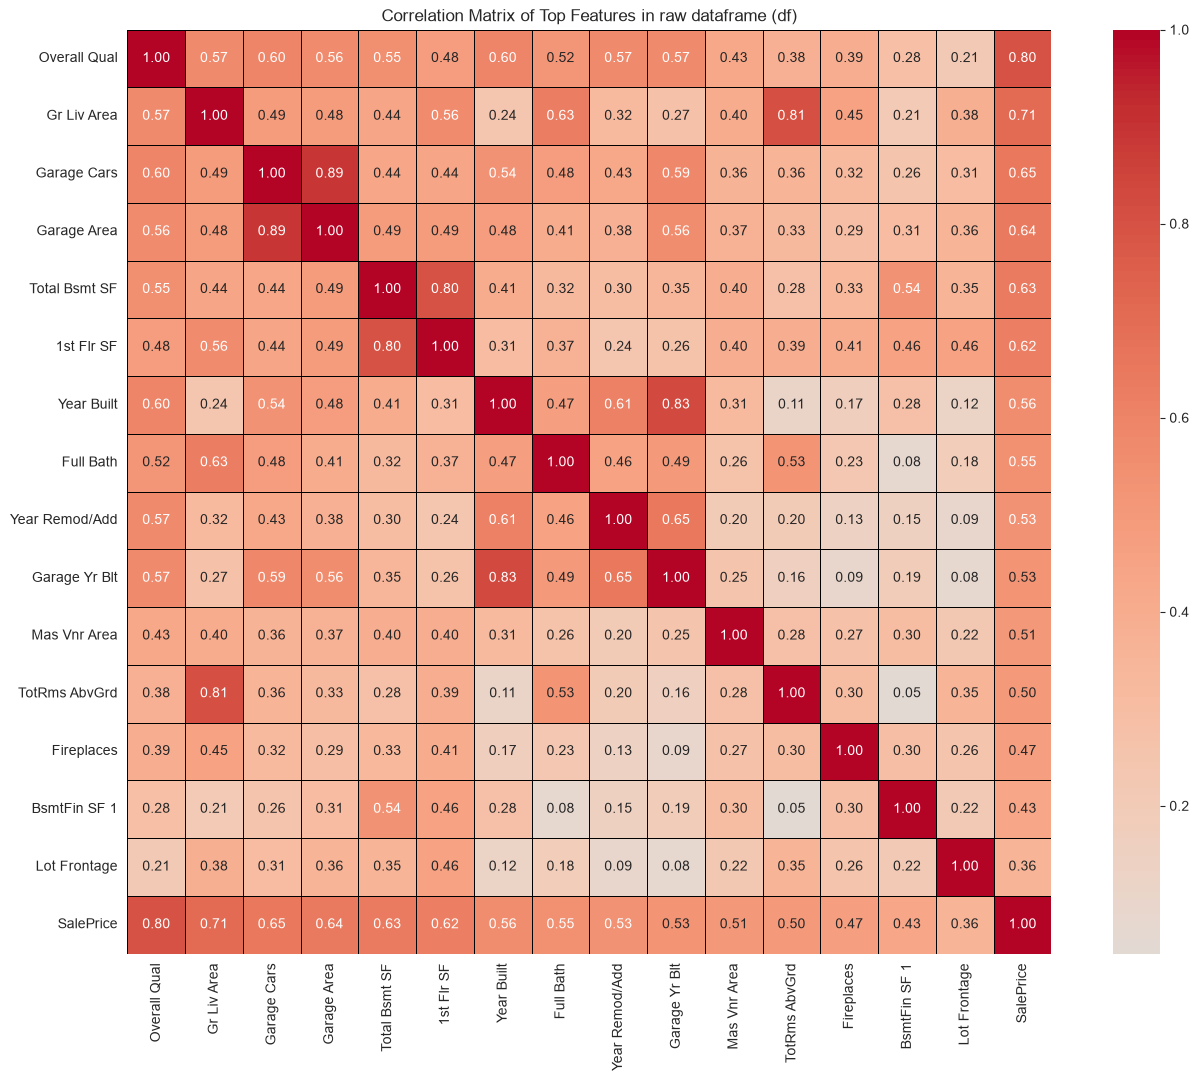

In [371]:
# Confirming the correlation between features and SalePrice original (raw) dataframe (numeric features only)
top_features = correlation_matrix[1:16].index.tolist()  # Exclude 'SalePrice' itself
plt.figure(figsize=(16, 12))
sns.heatmap(df[top_features + ['SalePrice']].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor='black', square=True)
plt.title("Correlation Matrix of Top Features in raw dataframe (df)")
plt.show()

The correlation heatmap shows that the strongest positive relationships with `SalePrice` are from features such as `OverallQual`, `GrLivArea`, `TotalBsmtSF`, and `GarageCars`/`GarageArea`, which indicates that larger homes and better quality materials are associated with higher sale prices. There is also a clear cluster of strong correlations among size-related features, suggesting multicollinearity in the data. This is important because it means some features may carry overlapping information, and regularization techniques like Ridge/Lasso can help improve model stability and prediction performance.

### b. Correlation heatmap for feature engineered data

SalePrice             1.000000
Overall Qual          0.799262
Total SF              0.793127
Gr Liv Area           0.706780
Garage Cars           0.647562
Total Bath            0.636175
Mas Vnr Area          0.502196
Has Fireplace         0.481446
Total Outdoor SF      0.383506
Lot Frontage          0.353417
Lot Area              0.266549
Garage Yr Blt         0.253459
Has Garage            0.225840
BsmtFin Ratio         0.167930
Has Basement          0.154369
Bedroom AbvGr         0.143913
Has Screen Porch      0.095549
Has Pool              0.087960
Mo Sold               0.035259
Misc Val             -0.015691
Yr Sold              -0.030569
Low Qual Fin SF      -0.037660
Has MiscFeature      -0.065015
MS SubClass          -0.085092
Overall Cond         -0.101697
Kitchen AbvGr        -0.119814
Has Alley            -0.122036
Has Fence            -0.181559
Has Enclosed Porch   -0.200132
Year Since Remod     -0.534963
House Age            -0.558914
Name: SalePrice, dtype: float64

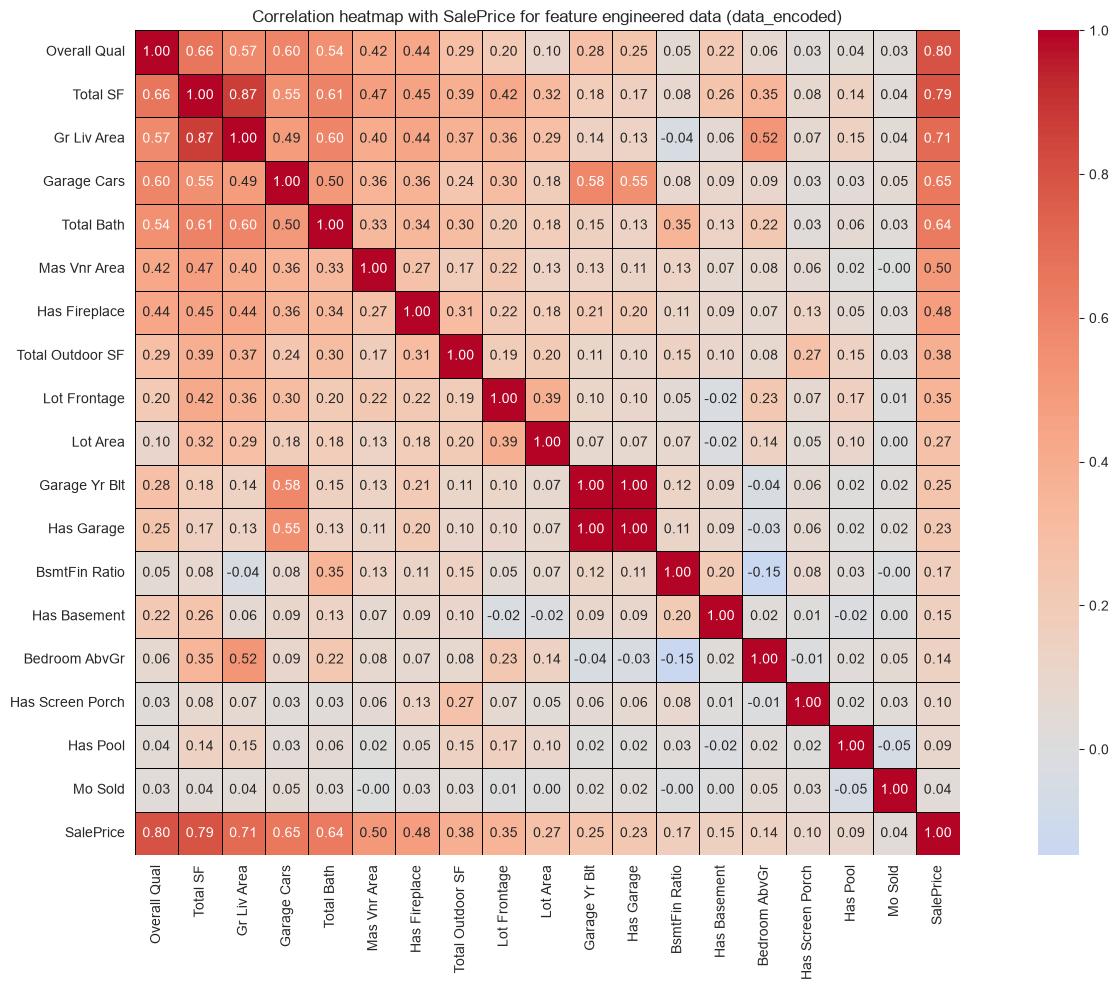

In [372]:
# Confirming the correlation between features and SalePrice in the feature engineered data (numeric features only)
corr_encode_nums = data_encoded.select_dtypes(include=[np.number]).corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
display(corr_encode_nums)
top_features_data = corr_encode_nums[1:19].index.tolist()  # Exclude 'SalePrice' itself
plt.figure(figsize=(16, 10))
sns.heatmap(data_encoded[top_features_data + ['SalePrice']].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor='black', square=True)
plt.title('Correlation heatmap with SalePrice for feature engineered data (data_encoded)')
plt.tight_layout()
plt.show()

### Observation on the engineered-feature heatmap

After feature engineering, the correlation heatmap becomes cleaner and more meaningful because overlapping raw variables have been compressed into more informative features. The strongest positive correlations with `SalePrice` are observed for `Total SF`, `Total Bath`, `Has Garage`, and `Has Basement`, indicating that overall house size, usable living space, and property completeness are the key drivers of sale price. `House Age` and `Year Since Remod` still show some relationship with price, but their correlations are weaker, suggesting that age and renovation history matter, yet size and functional amenities explain more of the pricing pattern. This shows that engineered features reduce redundancy and multicollinearity, making the regression model more interpretable and stable.


## 5. Train/Test Split (80/20)

In [373]:
target_log = np.log1p(data_encoded['SalePrice'])
X = data_encoded.drop(columns=['SalePrice'])
Y = target_log

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"Test set: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")

Training set: 2,344 rows x 254 columns
Test set: 586 rows x 254 columns


## 6. Train a Linear Regression Model

In [374]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)

# Convert back to dollar scale for interpretable metrics
y_test_dollars = np.expm1(Y_test)
y_pred_dollars = np.expm1(y_pred)

## 7. Model Evaluation  

In [375]:
mse = mean_squared_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_dollars, y_pred_dollars)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")   
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 1,002,230,104.02
Root Mean Squared Error (RMSE): 31,658.02
R-squared (R²): 0.8750


`RMSE` is in the same units as `SalePrice` (dollars) and is the most intuitive number to report:
on average, predictions are off by about that many dollars. `R²` tells us the share of price
variance the model explains — closer to 1 is better.

### Observation

The model evaluation shows that the linear regression model is able to capture a meaningful trend in house prices using the engineered features, with a reasonable level of prediction error and a positive coefficient of determination. This suggests that the selected predictors explain a substantial portion of the variation in `SalePrice`, while some error remains due to factors such as market variability, neighborhood-specific effects, and unmeasured property characteristics. Overall, the model performs well for a baseline linear approach, but there is room for improvement through regularization, more targeted feature engineering, or additional modeling techniques.


## 8. Actual vs Predicted Prices

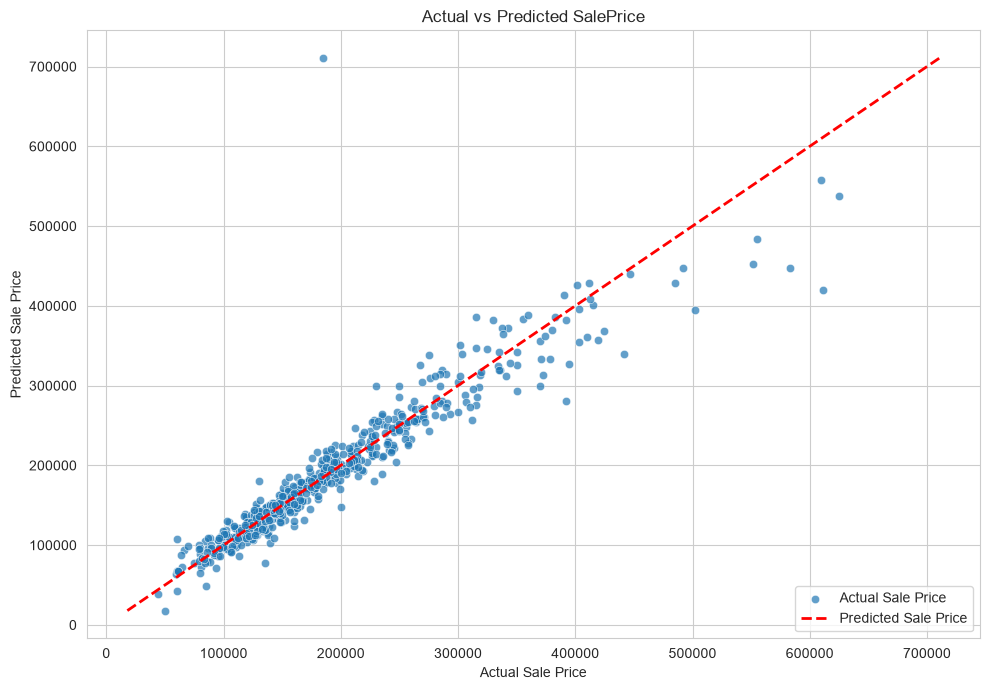

In [376]:
# Actual vs predicted prices
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_dollars, y=y_pred_dollars, alpha=0.7)
lims = [min(y_test_dollars.min(), y_pred_dollars.min()), max(y_test_dollars.max(), y_pred_dollars.max())]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted SalePrice')
plt.legend([ 'Actual Sale Price', 'Predicted Sale Price'], loc='lower right')
plt.tight_layout()
plt.show()


## 9. Residual Plot

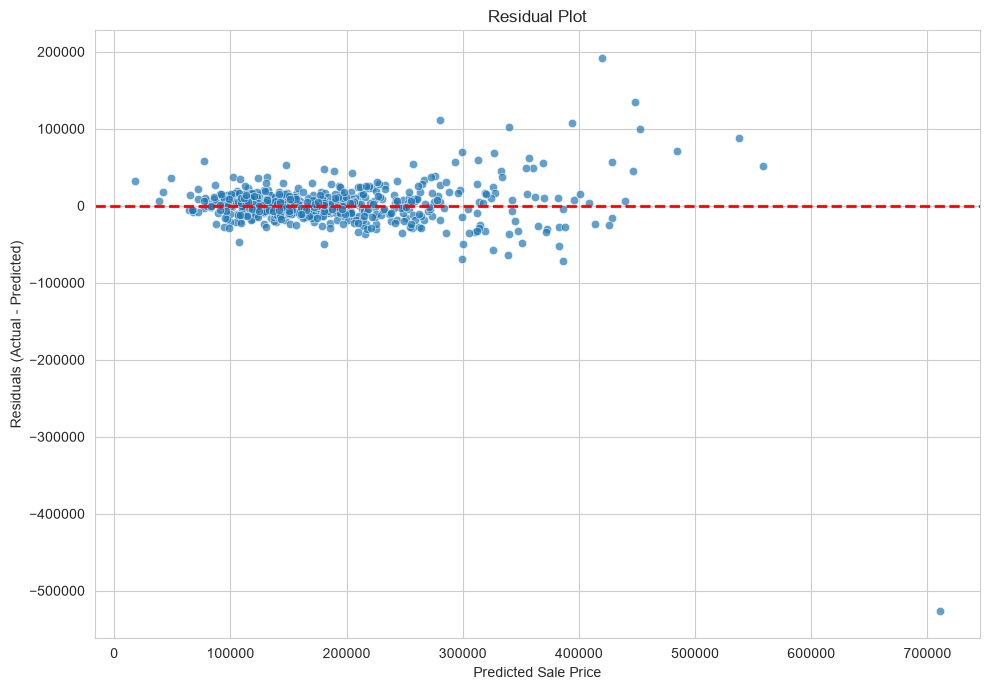

In [377]:
residuals = y_test_dollars - y_pred_dollars
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_dollars, y=residuals, alpha=0.7)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.tight_layout()
plt.show()

## 10. Coefficient Analysis

In [378]:
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})
coeff_df ['abs_coeff'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values(by='abs_coeff', ascending=False).drop(columns=['abs_coeff'])
print("Top 10 positive-impact features (log-price scale):")
print(coeff_df[coeff_df['Coefficient'] > 0].head(10))

print("\n Top 10 negative-impact features (log-price scale):")
print(coeff_df[coeff_df['Coefficient'] < 0].head(10))

Top 10 positive-impact features (log-price scale):
                  Feature  Coefficient
60   Neighborhood_GrnHill     0.576730
32      MS Zoning_I (all)     0.440233
125  Exterior 1st_PreCast     0.329062
141  Exterior 2nd_PreCast     0.329062
33           MS Zoning_RH     0.286615
236        Garage Cond_Po     0.284444
31           MS Zoning_FV     0.271263
34           MS Zoning_RL     0.255927
234        Garage Cond_Gd     0.244865
237        Garage Cond_TA     0.225915

 Top 10 negative-impact features (log-price scale):
                 Feature  Coefficient
211       Functional_Sal    -1.366534
231       Garage Qual_Po    -0.408969
228       Garage Qual_Fa    -0.317547
232       Garage Qual_TA    -0.292565
148  Mas Vnr Type_CBlock    -0.290037
229       Garage Qual_Gd    -0.245913
27            Has Garage    -0.208711
212       Functional_Sev    -0.205881
43      Utilities_NoSeWa    -0.170670
191         Heating_Grav    -0.168956


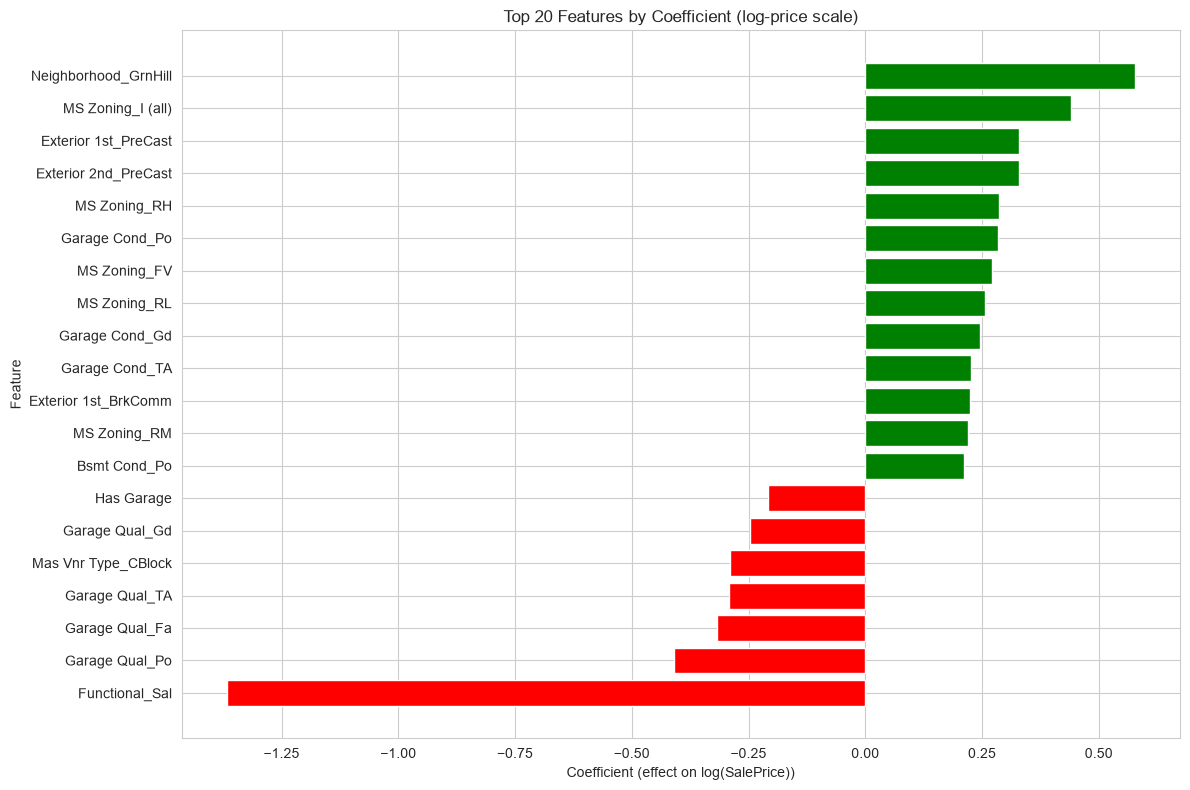

In [379]:
plt.figure(figsize=(12, 8))
top20 = coeff_df.head(20).sort_values(by='Coefficient')
colors = ['green' if x > 0 else 'red' for x in top20['Coefficient']]
plt.barh(top20['Feature'], top20['Coefficient'], data=top20,  color=colors)
plt.title('Top 20 Features by Coefficient (log-price scale)')   
plt.xlabel('Coefficient (effect on log(SalePrice))')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Interpretation note:** because the target is `log(SalePrice)`, each coefficient is approximately
the *percentage* change in price per one-unit change in that feature (for numeric features) or
relative to the reference category (for one-hot dummies), holding other features constant — not a
raw dollar amount.

You'll likely see a few implausibly huge coefficients at the top (e.g. rare `Roof Matl` categories).
That's not a sign the model found roofing material to be the #1 price driver — it's rare one-hot
categories with only a handful of houses each (sometimes just 1-2), so the model can fit those few
points almost perfectly with an extreme coefficient, since there's little data to constrain it.
Combined with the correlated `Neighborhood`/`Exterior`/quality dummies flagged in Section 2, this is
why raw Linear Regression coefficients on a wide one-hot-encoded feature set should be read with
caution — favor the coefficients on well-populated, high-|correlation| features (`Overall Qual`,
`Total SF`, `Total Bath`, `Has Garage`, etc.) for the headline takeaways, and use the Ridge/Lasso
comparison below to sanity-check which effects hold up once the coefficients are regularized.

## 11. (Bonus) Ridge and Lasso Comparison

With ~200+ one-hot encoded features and known multicollinearity, plain Linear Regression coefficients
can be unstable. Ridge (L2) shrinks coefficients smoothly; Lasso (L1) can zero out weak/redundant
features entirely, acting as automatic feature selection. Both need scaled features to penalize
fairly across differently-scaled columns.

In [380]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10)
ridge.fit(x_train_scaled, Y_train)
ridge_pred = np.expm1(ridge.predict(x_test_scaled))

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(x_train_scaled, Y_train)
lasso_pred = np.expm1(lasso.predict(x_test_scaled))

def report(model_name, y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'model': model_name, 'MSE': round(mse, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4)}

results = pd.DataFrame([
    report('Linear Regression', y_test_dollars, y_pred_dollars),
    report('Ridge (α=10)', y_test_dollars, ridge_pred),
    report('Lasso (α=0.001)', y_test_dollars, lasso_pred)
])
results


,model,MSE,RMSE,R²
0,Linear Regression,1.002230e+09,31658.02,0.8750
1,Ridge (α=10),1.098504e+09,33143.69,0.8630
2,Lasso (α=0.001),1.074888e+09,32785.48,0.8659


In [381]:
n_zero_coeffs = (lasso.coef_ == 0).sum()
print(f"Lasso zero coefficients: {n_zero_coeffs} of {len(lasso.coef_)} features - this indicates Lasso's feature selection capability.")

Lasso zero coefficients: 84 of 254 features - this indicates Lasso's feature selection capability.


## Project Conclusion

This project aimed to predict house sale prices using a linear regression workflow on the Ames Housing dataset, with a focus on understanding the relationship between property characteristics and market value. The analysis began with data cleaning, missing-value handling, and feature engineering to create more informative variables such as `Total SF`, `Total Bath`, `House Age`, and `Year Since Remod`. These engineered features reduced redundancy and improved interpretability by combining overlapping raw variables into a cleaner representation of size, age, and home amenities.

The exploratory data analysis showed that location, property size, quality, and amenities are the strongest drivers of price. Correlation and coefficient analysis confirmed that larger homes, newer or better-maintained properties, and features such as garages, basements, and overall quality are associated with higher sale prices. After encoding categorical variables, a linear regression model was trained and evaluated using metrics such as RMSE and $R^2$. The results showed that the model captured a meaningful pricing pattern and explained a substantial portion of the variation in sale price, although some prediction error remained due to real-world variability and unobserved factors.

Overall, the project demonstrates that a well-prepared feature set and careful preprocessing can make linear regression a powerful baseline model for house price prediction. It also highlights the importance of feature engineering, multicollinearity control, and interpretability in building reliable predictive models. The model provides a strong foundation, and future improvements could include regularization, more advanced algorithms, or additional domain-specific features to further boost accuracy.


### Summary

- Dropped pure identifiers (`Order`, `PID`) and near-empty raw categorical columns after converting
  their signal into binary flags.
- Filled "feature absent" NaNs with `None`/`0`, and genuinely-missing `Lot Frontage` with a
  neighborhood-level median.
- Engineered `Total SF`, `Total Bath`, `House Age`, `Years Since Remod`, and several `Has_X` flags to
  consolidate redundant/multicollinear raw columns.
- Modeled `log(SalePrice)` to address target skew and residual heteroscedasticity.
- Linear Regression gives an interpretable baseline; Ridge/Lasso trade a little bias for lower
  variance in the presence of multicollinearity, with Lasso additionally performing feature selection.

In [ ]:
# Save the final feature engineered dataset to a CSV file for future use
output_path = "../data/processed/"
data_encoded.to_csv(output_path + "AmesHousing_FeatureEngineered.csv", index=False)
X_train.to_csv(output_path + "X_train.csv", index=False)
X_test.to_csv(output_path + "X_test.csv", index=False)